# Data Preparation / Feature Engineering

## Business objective and success criteria
This project aims to predict Remaining Useful Life (RUL) for aircraft engines so maintenance can be scheduled before failures occur. In practice, the model should help reduce unplanned downtime, avoid costly emergency repairs, and support proactive maintenance planning.

A good model should:
- predict RUL early enough to allow action before failure,
- keep prediction errors low enough that maintenance decisions are reliable,
- and generalize well to unseen engines rather than only memorizing the training set.

For this notebook, we use RMSE, MAE, and R² on a held-out validation set as the primary success criteria. Lower RMSE/MAE and higher R² indicate better predictive performance.


In the previous step1_eda.ipynb, we have performed some statistical analysis and draw insights on how to prepare our preliminary dataset. Including:

Train/Val split:
1. Splits dataset into training and validation before standardization, standardization should fit on train set only.
2. Must maintain local chronological order for each engine.

Data cleaning:
1. Compute life_ratio as labels
2. Removing the columns: settings1, settings2, settings3, engine_id (drop when training), T2, P2, farB, NF_dmd, PCNfR_dmd, and Nrc

Feature Scaling:
1. Sensor features are standardized using statistics computed exclusively from the training set.
2. The same transformation is applied to validation data to ensure consistency and prevent data leakage.

Feature Engineering: 
1. Compute rolling window statistics feature for sensors, grouped by engine_id.
2. Compute lags of current timestep.

In [372]:
import pandas as pd
import sys
sys.path.append("..")
from src.const import SENSOR_NAMES

columns = ['engine_id', 'cycle'] + SENSOR_NAMES

df = pd.read_csv("../data/raw/train_FD001.txt", sep=r'\s+', header=None,
                       usecols=range(len(columns)), names=columns, engine='python')

### Train/Val split

In [373]:
from sklearn.model_selection import train_test_split
# -----------------------------
# 1. Train/Validation split by engine_id
# -----------------------------
engine_ids = df["engine_id"].unique()

train_ids, val_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_ids)].copy()
val_df   = df[df["engine_id"].isin(val_ids)].copy()

# -----------------------------
# 2. Maintain local chronological order per engine
# -----------------------------
train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
val_df   = val_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# -----------------------------
# 3. Sanity checks
# -----------------------------
assert set(train_df["engine_id"]).isdisjoint(set(val_df["engine_id"])), "Leakage detected!"
assert train_df["cycle"].is_monotonic_increasing is False or True  # per-engine ordering enforced

print("Train engines:", train_df["engine_id"].nunique())
print("Val engines:", val_df["engine_id"].nunique())
print("Split complete without engine leakage.")

Train engines: 80
Val engines: 20
Split complete without engine leakage.


In [374]:
train_df

,engine_id,cycle,T2,T24,T30,T50,P2,P15,P30,Nf,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,9054.72,1.3,46.93,522.33,2388.06,8137.72,8.3905,0.03,391,2388
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,9051.31,1.3,47.24,522.70,2387.98,8131.09,8.4167,0.03,392,2388
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,9054.24,1.3,47.22,522.58,2387.99,8140.58,8.3802,0.03,391,2388
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,9058.01,1.3,47.10,522.49,2387.93,8140.44,8.4018,0.03,391,2388
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,9058.15,1.3,47.25,522.27,2387.94,8136.67,8.3867,0.03,390,2388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388
16557,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388
16558,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388
16559,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388


In [375]:
val_df

,engine_id,cycle,T2,T24,T30,T50,P2,P15,P30,Nf,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0010,-0.0000,100.0,518.67,642.98,1600.49,1427.11,14.62,...,9045.20,1.3,48.24,519.76,2388.28,8119.61,8.5282,0.03,395,2388
4066,91,132,-0.0025,-0.0003,100.0,518.67,643.91,1596.94,1428.41,14.62,...,9041.93,1.3,48.02,519.76,2388.30,8120.68,8.5323,0.03,397,2388
4067,91,133,0.0012,-0.0001,100.0,518.67,644.22,1602.83,1426.55,14.62,...,9049.93,1.3,48.07,519.35,2388.26,8120.11,8.5183,0.03,396,2388
4068,91,134,0.0004,0.0006,100.0,518.67,643.70,1606.40,1430.92,14.62,...,9052.04,1.3,48.20,519.43,2388.33,8119.01,8.5215,0.03,396,2388


In [376]:
train_df.nunique()

engine_id      80
cycle         362
T2            156
T24            13
T30             1
T50             1
P2            305
P15          2878
P30          3893
Nf              1
Nc              2
epr           501
Ps30           53
phi          5911
NRf             1
NRc           155
BPR           425
farB           55
htBleed      5652
Nf_dmd       1871
PCNfR_dmd       1
W31            13
W32             1
dtype: int64

In [377]:
val_df.nunique()

engine_id      20
cycle         269
T2            133
T24            13
T30             1
T50             1
P2            276
P15          1976
P30          2409
Nf              1
Nc              2
epr           454
Ps30           43
phi          2729
NRf             1
NRc           144
BPR           366
farB           45
htBleed      2678
Nf_dmd       1410
PCNfR_dmd       1
W31            11
W32             1
dtype: int64

### Preprocess

In [378]:
# -----------------------------
# 1. Compute life_ratio
# -----------------------------
def add_rul(df, engine_col="engine_id", cycle_col="cycle"):
    """
    Adds a Remaining Useful Life (RUL) column to a CMAPSS dataframe.

    RUL = max_cycle - current_cycle, computed independently for each engine.
    """
    df = df.copy()

    df["max_cycle"] = df.groupby(engine_col)[cycle_col].transform("max")
    df["RUL"] = df["max_cycle"] - df[cycle_col]

    df.drop(columns=["max_cycle"], inplace=True)

    return df

# -----------------------------
# 2. Drop unwanted columns
# -----------------------------
def clean_features(df, cols_to_drop=[]):
    df = df.copy()
    # drop feature columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

# -----------------------------
# 3. Full preprocessing pipeline
# -----------------------------
def preprocess(df, cols_to_drop=[]):
    # df = add_life_ratio(df)
    df = add_rul(df)
    df = clean_features(df, cols_to_drop)
    return df

In [379]:
cols_to_drop = [
    "setting_1", "setting_2", "setting_3",
    "T2", "P2", "farB", "NF_dmd", "PCNfR_dmd", "Nrc",
    "P15", "P30", "epr"
]
# cols_to_drop = []
train_df = preprocess(train_df, cols_to_drop=cols_to_drop)
val_df   = preprocess(val_df, cols_to_drop=cols_to_drop)

In [380]:
train_df

,engine_id,cycle,T24,T30,T50,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,Nf_dmd,W31,W32,RUL
0,2,1,0.0006,100.0,518.67,14.62,21.60,2388.01,9054.72,1.3,46.93,522.33,8137.72,8.3905,391,2388,286
1,2,2,-0.0003,100.0,518.67,14.62,21.61,2387.98,9051.31,1.3,47.24,522.70,8131.09,8.4167,392,2388,285
2,2,3,0.0003,100.0,518.67,14.62,21.60,2388.04,9054.24,1.3,47.22,522.58,8140.58,8.3802,391,2388,284
3,2,4,-0.0004,100.0,518.67,14.62,21.61,2387.98,9058.01,1.3,47.10,522.49,8140.44,8.4018,391,2388,283
4,2,5,0.0004,100.0,518.67,14.62,21.60,2388.03,9058.15,1.3,47.25,522.27,8136.67,8.3867,390,2388,282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0003,100.0,518.67,14.62,21.61,2388.19,9065.52,1.3,48.07,519.49,8137.60,8.4956,397,2388,4
16557,100,197,-0.0005,100.0,518.67,14.62,21.61,2388.23,9065.11,1.3,48.04,519.68,8136.50,8.5139,395,2388,3
16558,100,198,0.0000,100.0,518.67,14.62,21.61,2388.24,9065.90,1.3,48.09,520.01,8141.05,8.5646,398,2388,2
16559,100,199,0.0003,100.0,518.67,14.62,21.61,2388.25,9073.72,1.3,48.39,519.67,8139.29,8.5389,395,2388,1


In [381]:
val_df

,engine_id,cycle,T24,T30,T50,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,Nf_dmd,W31,W32,RUL
0,1,1,-0.0004,100.0,518.67,14.62,21.61,2388.06,9046.19,1.3,47.47,521.66,8138.62,8.4195,392,2388,191
1,1,2,-0.0003,100.0,518.67,14.62,21.61,2388.04,9044.07,1.3,47.49,522.28,8131.49,8.4318,392,2388,190
2,1,3,0.0003,100.0,518.67,14.62,21.61,2388.08,9052.94,1.3,47.27,522.42,8133.23,8.4178,390,2388,189
3,1,4,0.0000,100.0,518.67,14.62,21.61,2388.11,9049.48,1.3,47.13,522.86,8133.83,8.3682,392,2388,188
4,1,5,-0.0002,100.0,518.67,14.62,21.61,2388.06,9055.15,1.3,47.28,522.19,8133.80,8.4294,393,2388,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0000,100.0,518.67,14.62,21.61,2388.26,9045.20,1.3,48.24,519.76,8119.61,8.5282,395,2388,4
4066,91,132,-0.0003,100.0,518.67,14.62,21.61,2388.30,9041.93,1.3,48.02,519.76,8120.68,8.5323,397,2388,3
4067,91,133,-0.0001,100.0,518.67,14.62,21.61,2388.29,9049.93,1.3,48.07,519.35,8120.11,8.5183,396,2388,2
4068,91,134,0.0006,100.0,518.67,14.62,21.61,2388.27,9052.04,1.3,48.20,519.43,8119.01,8.5215,396,2388,1


### Feature Scaling

In [382]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define sensor columns
# -----------------------------
def get_sensor_columns(df):
    return df.select_dtypes(include=["float64", "int64"]).columns.drop(
        ["RUL", "cycle", "engine_id"], errors="ignore"
    )

sensor_cols = get_sensor_columns(train_df)

# -----------------------------
# 2. Fit scaler ONLY on training set
# -----------------------------
scaler = StandardScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()

scaler.fit(train_df_scaled[sensor_cols])

train_df_scaled[sensor_cols] = scaler.transform(train_df_scaled[sensor_cols])
val_df_scaled[sensor_cols] = scaler.transform(val_df_scaled[sensor_cols])

# -----------------------------
# 3. Sanity check
# -----------------------------
print("Scaling complete.")
print("Train shape:", train_df_scaled.shape)
print("Val shape:", val_df_scaled.shape)

Scaling complete.
Train shape: (16561, 17)
Val shape: (4070, 17)


In [383]:
train_df_scaled

,engine_id,cycle,T24,T30,T50,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,Nf_dmd,W31,W32,RUL
0,2,1,2.043793,0.0,0.0,-5.329071e-15,-7.193194,-1.221017,-0.471297,-2.220446e-16,-2.294365,1.242127,-0.315944,-1.373754,-1.426246,0.0,286
1,2,2,-1.031739,0.0,0.0,-5.329071e-15,0.139020,-1.645675,-0.621789,-2.220446e-16,-1.127747,1.745551,-0.654442,-0.675217,-0.779529,0.0,285
2,2,3,1.018616,0.0,0.0,-5.329071e-15,-7.193194,-0.796358,-0.492481,-2.220446e-16,-1.203012,1.582278,-0.169925,-1.648369,-1.426246,0.0,284
3,2,4,-1.373465,0.0,0.0,-5.329071e-15,0.139020,-1.645675,-0.326102,-2.220446e-16,-1.654606,1.459824,-0.177072,-1.072476,-1.426246,0.0,283
4,2,5,1.360341,0.0,0.0,-5.329071e-15,-7.193194,-0.937911,-0.319923,-2.220446e-16,-1.090114,1.160491,-0.369552,-1.475068,-2.072963,0.0,282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-1.031739,0.0,0.0,-5.329071e-15,0.139020,1.326935,0.005332,-2.220446e-16,1.995779,-2.621987,-0.322070,1.428392,2.454058,0.0,4
16557,100,197,-1.715191,0.0,0.0,-5.329071e-15,0.139020,1.893147,-0.012762,-2.220446e-16,1.882880,-2.363472,-0.378231,1.916301,1.160624,0.0,3
16558,100,198,-0.006562,0.0,0.0,-5.329071e-15,0.139020,2.034700,0.022102,-2.220446e-16,2.071044,-1.914473,-0.145928,3.268050,3.100776,0.0,2
16559,100,199,1.018616,0.0,0.0,-5.329071e-15,0.139020,2.176253,0.367217,-2.220446e-16,3.200030,-2.377078,-0.235786,2.582844,1.160624,0.0,1


In [384]:
train_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,Nf_dmd,W31,W32,RUL
count,16561.000000,16561.000000,1.656100e+04,16561.0,16561.0,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,16561.0,16561.000000
mean,53.022704,109.377815,-2.231038e-17,0.0,0.0,-5.329071e-15,-3.899311e-12,-1.117482e-12,1.123757e-14,-2.220446e-16,-3.514743e-15,1.054938e-13,3.933492e-15,-4.222154e-14,-1.643417e-14,0.0,108.377815
std,29.258544,69.639875,1.000030e+00,0.0,0.0,0.000000e+00,1.000030e+00,1.000030e+00,1.000030e+00,0.000000e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,0.0,69.639875
min,2.000000,1.000000,-2.056917e+00,0.0,0.0,-5.329071e-15,-7.193194e+00,-2.778098e+00,-1.927223e+00,-2.220446e-16,-2.595427e+00,-3.710470e+00,-2.244824e+00,-3.042777e+00,-3.366398e+00,0.0,0.000000
25%,27.000000,52.000000,-6.900133e-01,0.0,0.0,-5.329071e-15,1.390203e-01,-6.548050e-01,-5.410265e-01,-2.220446e-16,-7.137854e-01,-6.218996e-01,-5.313983e-01,-7.232079e-01,-7.795285e-01,0.0,51.000000
50%,55.000000,104.000000,-6.561730e-03,0.0,0.0,-5.329071e-15,1.390203e-01,-8.859342e-02,-1.981182e-01,-2.220446e-16,-1.116601e-01,9.922029e-02,-1.592030e-01,-8.865916e-02,-1.328112e-01,0.0,103.000000
75%,79.000000,157.000000,1.018616e+00,0.0,0.0,-5.329071e-15,1.390203e-01,6.191710e-01,1.761241e-01,-2.220446e-16,6.033638e-01,7.250979e-01,2.232035e-01,6.152100e-01,5.139062e-01,0.0,156.000000
max,100.000000,362.000000,2.043793e+00,0.0,0.0,-5.329071e-15,1.390203e-01,6.564392e+00,7.908111e+00,-2.220446e-16,3.689256e+00,2.670761e+00,7.648730e+00,3.806617e+00,4.394210e+00,0.0,361.000000


In [385]:
val_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,Nf_dmd,W31,W32,RUL
count,4070.000000,4070.000000,4070.000000,4070.0,4070.0,4.070000e+03,4070.000000,4070.000000,4070.000000,4.070000e+03,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.0,4070.000000
mean,45.337346,106.488698,0.007460,0.0,0.0,-5.329071e-15,-0.026720,0.028196,-0.034953,-2.220446e-16,0.028562,-0.024872,-0.040245,0.016251,0.017348,0.0,105.488698
std,28.278657,65.659973,1.007403,0.0,0.0,0.000000e+00,1.089985,1.023892,0.862803,0.000000e+00,1.025404,1.017466,0.859039,0.999633,1.008026,0.0,65.659973
min,1.000000,1.000000,-2.056917,0.0,0.0,-5.329071e-15,-7.193194,-2.494992,-1.420143,-2.220446e-16,-2.407263,-3.207046,-1.683723,-3.122762,-2.719681,0.0,0.000000
25%,19.000000,51.000000,-1.031739,0.0,0.0,-5.329071e-15,0.139020,-0.796358,-0.546764,-2.220446e-16,-0.751418,-0.676324,-0.584879,-0.725208,-0.779529,0.0,50.000000
50%,45.000000,102.000000,-0.006562,0.0,0.0,-5.329071e-15,0.139020,0.052959,-0.256814,-2.220446e-16,-0.036394,0.031190,-0.215364,-0.048667,-0.132811,0.0,101.000000
75%,77.000000,154.000000,1.018616,0.0,0.0,-5.329071e-15,0.139020,0.760724,0.185723,-2.220446e-16,0.678629,0.738704,0.230224,0.684530,0.513906,0.0,153.000000
max,91.000000,269.000000,2.043793,0.0,0.0,-5.329071e-15,0.139020,3.450229,4.442398,-2.220446e-16,3.726889,2.303398,4.438354,3.353368,3.747493,0.0,268.000000


### Feature Engineering (Adding rolling window and lags):
- Useful for Tree models

In [393]:
import numpy as np

WINDOW = 5
LAGS = [1, 2]

def add_time_series_features(df, sensor_cols):
    df = df.copy()
    df = df.sort_values(["engine_id", "cycle"])

    group_cols = ["engine_id"]

    # -------------------------
    # Rolling mean features
    # -------------------------
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(group_cols)[col]
              .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
        )

    # -------------------------
    # Lag features
    # -------------------------
    for col in sensor_cols:
        for lag in LAGS:
            df[f"{col}_lag{lag}"] = (
                df.groupby(group_cols)[col]
                  .shift(lag)
            )

    return df

In [394]:
def fit_feature_selector(train_df, target="RUL", top_k=10):
    # keep ONLY numeric columns
    numeric_df = train_df.select_dtypes(include=["number"]).copy()

    feature_cols = numeric_df.columns.drop([target], errors="ignore")

    corr = numeric_df[feature_cols].corrwith(numeric_df[target]).abs()
    var = numeric_df[feature_cols].var()

    score = corr * var

    score_df = (
        pd.DataFrame({
            "correlation": corr,
            "variance": var,
            "score": score
        })
        .sort_values(by="score", ascending=False)
    )

    print("\n===== Feature Scores (Top 20) =====")
    print(score_df.head(20))

    # -------------------------
    # top-k logic fix
    # -------------------------
    if top_k == -1:
        top_features = score_df.index.tolist()
        print("\nSelected ALL features")
    else:
        top_features = score_df.head(top_k).index.tolist()
        print(f"\nSelected Top {top_k} Features:")

    print(top_features)

    return top_features

In [395]:
def get_sensor_columns(df):
    exclude = {"RUL", "cycle", "engine_id"}

    return [
        c for c in df.select_dtypes(include=["number"]).columns
        if c not in exclude
    ]

In [463]:
def apply_feature_selection(df, selected_features, target="RUL"):
    if "cycle" not in selected_features:
        selected_features.append("cycle")
    if "engine_id" not in selected_features:
        selected_features.append("engine_id")
    keep_cols = [target] + selected_features
    return df[keep_cols].copy()

In [397]:
def feature_engineering_pipeline(train_df, val_df, top_k=10):
    # -------------------------
    # 1. sensor columns from TRAIN ONLY
    # -------------------------
    sensor_cols = get_sensor_columns(train_df)

    # -------------------------
    # 2. Feature engineering
    # -------------------------
    train_fe = add_time_series_features(train_df, sensor_cols)
    val_fe   = add_time_series_features(val_df, sensor_cols)
    # train_fe = train_df
    # val_fe = val_df

    # handle NaNs from lag
    train_fe = train_fe.dropna().reset_index(drop=True)
    val_fe   = val_fe.dropna().reset_index(drop=True)

    # -------------------------
    # 3. Feature selection (TRAIN ONLY)
    # -------------------------
    selected_features = fit_feature_selector(train_fe, top_k=top_k)

    print("Top selected features:", selected_features)

    # -------------------------
    # 4. Apply selection
    # -------------------------
    train_final = apply_feature_selection(train_fe, selected_features)
    val_final   = apply_feature_selection(val_fe, selected_features)

    return train_final, val_final, selected_features

In [464]:
train_final, val_final, selected_features = feature_engineering_pipeline(
    train_df_scaled,
    val_df_scaled,
    top_k=10
)


===== Feature Scores (Top 20) =====
                  correlation     variance        score
cycle                0.717950  4782.378682  3433.506745
engine_id            0.094586   856.267425    80.991278
NRc                  0.684626     0.999654     0.684389
NRc_lag1             0.679900     0.975917     0.663526
BPR                  0.658493     1.000597     0.658886
NRc_lag2             0.675182     0.952378     0.643029
BPR_lag1             0.653159     0.976480     0.637797
Nf_dmd               0.632383     1.001738     0.633482
BPR_lag2             0.648214     0.955295     0.619236
Nf_dmd_lag1          0.626809     0.980946     0.614866
NRc_roll_mean        0.720711     0.836765     0.603065
W31                  0.596512     0.999805     0.596395
Nf_dmd_lag2          0.620682     0.958810     0.595116
W31_lag1             0.590319     0.978922     0.577876
BPR_roll_mean        0.698952     0.821831     0.574420
W31_lag2             0.584985     0.962284     0.562921
Ps30       

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [465]:
train_final

,RUL,cycle,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,Nf_dmd,BPR_lag2,Nf_dmd_lag1
0,284,3,2,-1.203012,-1.127747,1.582278,-2.294365,1.745551,-1.648369,1.242127,-0.675217
1,283,4,2,-1.654606,-1.203012,1.459824,-1.127747,1.582278,-1.072476,1.745551,-1.648369
2,282,5,2,-1.090114,-1.654606,1.160491,-1.203012,1.459824,-1.475068,1.582278,-1.072476
3,281,6,2,-1.842771,-1.090114,1.881611,-1.654606,1.160491,-1.653702,1.459824,-1.475068
4,280,7,2,-1.654606,-1.842771,0.983613,-1.090114,1.881611,-1.277771,1.160491,-1.653702
...,...,...,...,...,...,...,...,...,...,...,...
16396,4,196,100,1.995779,2.560271,-2.621987,2.183943,-2.322654,1.428392,-2.540351,2.929446
16397,3,197,100,1.882880,1.995779,-2.363472,2.560271,-2.621987,1.916301,-2.322654,1.428392
16398,2,198,100,2.071044,1.882880,-1.914473,1.995779,-2.363472,3.268050,-2.621987,1.916301
16399,1,199,100,3.200030,2.071044,-2.377078,1.882880,-1.914473,2.582844,-2.363472,3.268050


In [466]:
val_final

,RUL,cycle,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,Nf_dmd,BPR_lag2,Nf_dmd_lag1
0,189,3,1,-1.014848,-0.186926,1.364582,-0.262191,1.174097,-0.645889,0.330523,-0.272625
1,188,4,1,-1.541708,-1.014848,1.963247,-0.186926,1.364582,-1.968310,1.174097,-0.645889
2,187,5,1,-0.977215,-1.541708,1.051643,-1.014848,1.963247,-0.336613,1.364582,-1.968310
3,186,6,1,-1.428809,-0.977215,0.357735,-1.541708,1.051643,-0.832521,1.963247,-0.336613
4,185,7,1,-0.676153,-1.428809,1.228521,-0.977215,0.357735,-1.189788,1.051643,-0.832521
...,...,...,...,...,...,...,...,...,...,...,...
4025,4,131,91,2.635537,2.372107,-2.254624,1.769982,-2.200200,2.297564,-2.390684,1.900304
4026,3,132,91,1.807615,2.635537,-2.254624,2.372107,-2.254624,2.406877,-2.200200,2.297564
4027,2,133,91,1.995779,1.807615,-2.812471,2.635537,-2.254624,2.033613,-2.254624,2.406877
4028,1,134,91,2.485006,1.995779,-2.703623,1.807615,-2.812471,2.118930,-2.254624,2.033613


In [471]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = "RUL"

X_train = train_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_train = train_final[TARGET]

X_val = val_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_val = val_final[TARGET]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

In [472]:
def evaluate(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{ name } Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 14.6273
MAE : 10.4524
R2  : 0.9553

Validation Performance:
RMSE: 31.3241
MAE : 24.2993
R2  : 0.7687


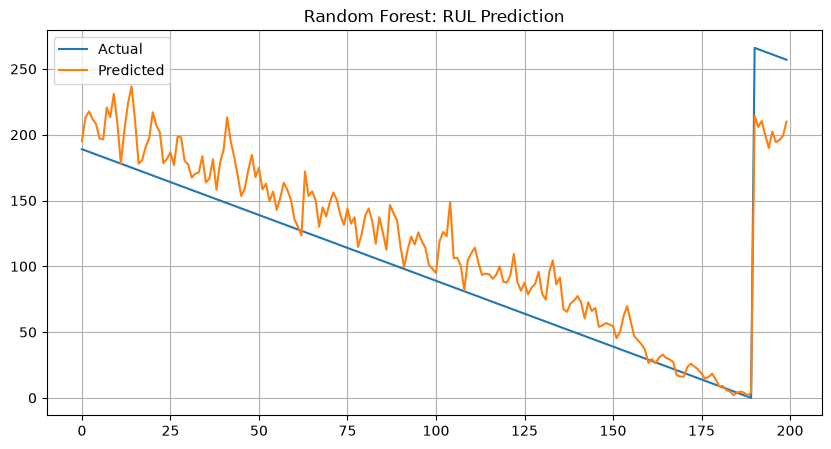

In [403]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: RUL Prediction")
plt.legend()
plt.grid()
plt.show()

Model overpredicts

### Hyperparameter tuning with Optuna

In [404]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [505]:
# Hyperparameter tuning random forest
besr_rf = None
best_rmse = None

def rf_objective(trial):
    global besr_rf, best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8, None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if best_rmse is None or rmse < best_rmse:
        best_rmse = rmse
        besr_rf = model

    return rmse


In [510]:
study = optuna.create_study(direction="minimize")
study.optimize(rf_objective, n_trials=100)

[I 2026-07-04 01:53:06,717] A new study created in memory with name: no-name-2c0fa583-9754-4cc4-ae58-099802458c57
[I 2026-07-04 01:53:08,135] Trial 0 finished with value: 30.75783918740646 and parameters: {'n_estimators': 496, 'max_depth': 65, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 0.8, 'bootstrap': True}. Best is trial 0 with value: 30.75783918740646.
[I 2026-07-04 01:53:08,657] Trial 1 finished with value: 30.222400295852964 and parameters: {'n_estimators': 260, 'max_depth': 32, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 30.222400295852964.
[I 2026-07-04 01:53:08,980] Trial 2 finished with value: 30.53526435343069 and parameters: {'n_estimators': 166, 'max_depth': 92, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 30.222400295852964.
[I 2026-07-04 01:53:09,477] Trial 3 finished with value: 30.295661532221928 and p

In [511]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 29.436004495665458
Best params: {'n_estimators': 584, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}


In [512]:
y_pred_train = besr_rf.predict(X_train)
y_pred_val = besr_rf.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 36.8598
MAE : 26.3455
R2  : 0.7159

Validation Performance:
RMSE: 29.4360
MAE : 22.7908
R2  : 0.7958


In [432]:
import xgboost as xgb

best_xg = None
xgb_best_rmse = None


def xgb_objective(trial):
    global best_xg, xgb_best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror",
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if xgb_best_rmse is None or rmse < xgb_best_rmse:
        xgb_best_rmse = rmse
        best_xg = model

    return rmse


In [449]:
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=100)

[I 2026-07-04 00:55:15,991] A new study created in memory with name: no-name-c6e3023a-238f-4c46-8782-64510fcb76b8
[I 2026-07-04 00:55:17,305] Trial 0 finished with value: 31.370267594728034 and parameters: {'n_estimators': 478, 'max_depth': 7, 'learning_rate': 0.05333144675745959, 'subsample': 0.5630470473311547, 'colsample_bytree': 0.5385124817990303, 'min_child_weight': 10, 'gamma': 1.7024785492357986, 'reg_alpha': 4.594890292611369, 'reg_lambda': 3.746760784927389}. Best is trial 0 with value: 31.370267594728034.
[I 2026-07-04 00:55:17,731] Trial 1 finished with value: 32.14159537609035 and parameters: {'n_estimators': 343, 'max_depth': 3, 'learning_rate': 0.29158290896427896, 'subsample': 0.5817364593533887, 'colsample_bytree': 0.9102107636419361, 'min_child_weight': 1, 'gamma': 2.9798807318748315, 'reg_alpha': 3.758951577591161, 'reg_lambda': 2.9574313440761326}. Best is trial 0 with value: 31.370267594728034.
[I 2026-07-04 00:55:17,963] Trial 2 finished with value: 30.09104024664

In [450]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 29.21553604482928
Best params: {'n_estimators': 288, 'max_depth': 3, 'learning_rate': 0.022002769076101904, 'subsample': 0.8323848289409395, 'colsample_bytree': 0.5175520606525121, 'min_child_weight': 8, 'gamma': 4.935053822320351, 'reg_alpha': 3.2553534254855845, 'reg_lambda': 1.6013319994716317}


In [436]:
best_xg

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5350467782737524
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [504]:
y_pred_train = best_xg.predict(X_train)
y_pred_val = best_xg.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 38.4226
MAE : 27.5900
R2  : 0.6913

Validation Performance:
RMSE: 29.2008
MAE : 22.6385
R2  : 0.7990


Optuna improved the RMSE from ~31 to ~29 on the val set.

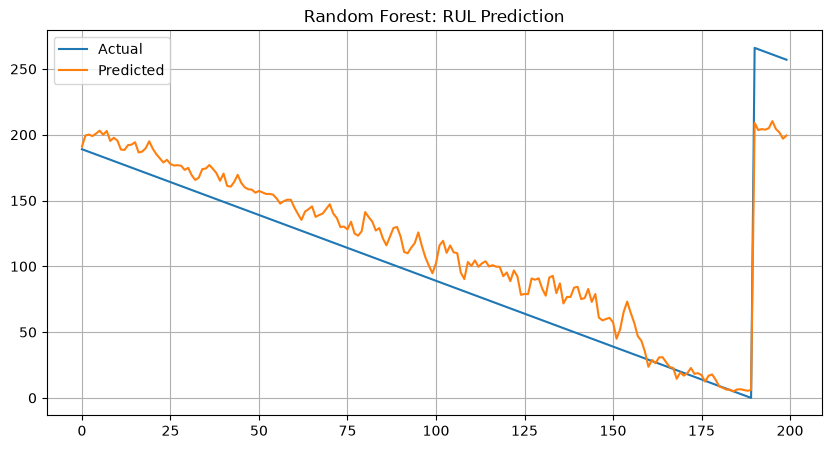

In [453]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: RUL Prediction")
plt.legend()
plt.grid()
plt.show()

## Model comparison table

The validation-set results for the models trained in this notebook are summarized below:

| Model | Dataset | RMSE | MAE | R² |
|---|---|---:|---:|---:|
| Random Forest (Optuna-tuned) | Validation | 29.4360 | 22.7908 | 0.7958 |
| XGBoost (Optuna-tuned) | Validation | 29.2008 | 22.6385 | 0.7990 |

These results suggest that the XGBoost model outperformed the Random Forest baseline on the validation set for this task.

### Interpretable / Explainable predictions using SHAP

In [513]:
import shap

X_sample = X_val.sample(n=10, random_state=42)

explainer = shap.TreeExplainer(best_xg)
shap_values = explainer(X_sample)



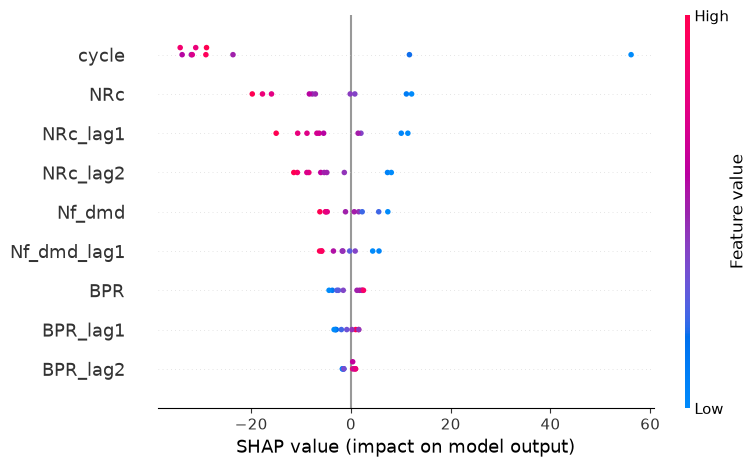

In [514]:
shap.plots.beeswarm(shap_values)

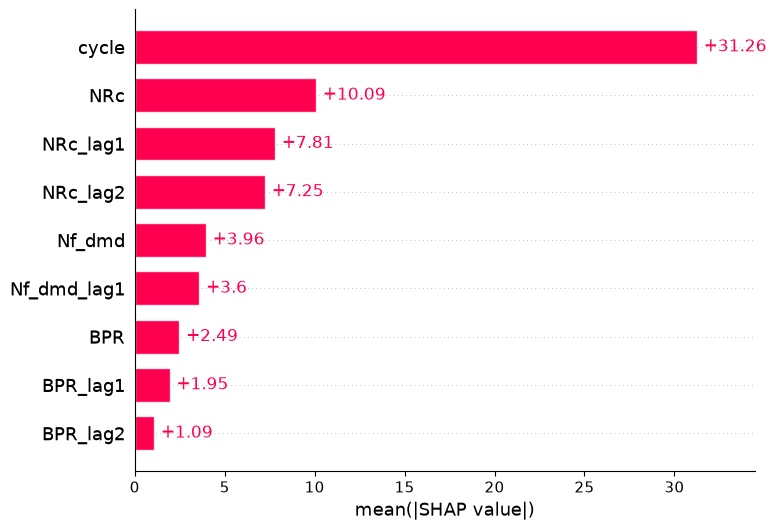

In [515]:
shap.plots.bar(shap_values)

Based on the shap plots, cycle and NRc contributes more to the prediction.

# Evaluation on test set

In [473]:
import pandas as pd
from src.const import SENSOR_NAMES

# Read raw test data using the same schema as the training data
columns = ["engine_id", "cycle"] + SENSOR_NAMES

# Load the raw test file and the provided RUL values
raw_test = pd.read_csv(
    "../data/raw/test_FD001.txt",
    sep=r"\s+",
    header=None,
    usecols=range(len(columns)),
    names=columns,
    engine="python",
)
raw_rul = pd.read_csv("../data/raw/RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Apply the same preprocessing as training data
raw_test = preprocess(raw_test, cols_to_drop=cols_to_drop)

# Reconstruct RUL for every observed cycle using the provided terminal RUL values
engine_ids = raw_test["engine_id"].unique()
if len(raw_rul) != len(engine_ids):
    raise ValueError(f"Expected {len(engine_ids)} RUL values, got {len(raw_rul)}")

rul_map = dict(zip(engine_ids, raw_rul.tolist()))
raw_test["rul_at_last_cycle"] = raw_test["engine_id"].map(rul_map)
raw_test["last_cycle"] = raw_test.groupby("engine_id")["cycle"].transform("max")
raw_test["RUL"] = raw_test["rul_at_last_cycle"] + (raw_test["last_cycle"] - raw_test["cycle"])
raw_test = raw_test.drop(columns=["rul_at_last_cycle", "last_cycle"])

# Scale using the training-set scaler and create the same engineered features
sensor_cols = get_sensor_columns(raw_test)
raw_test_scaled = raw_test.copy()
raw_test_scaled[sensor_cols] = scaler.transform(raw_test_scaled[sensor_cols])

raw_test_fe = add_time_series_features(raw_test_scaled, sensor_cols)
raw_test_fe = raw_test_fe.dropna().reset_index(drop=True)

# Keep the same feature columns used during model training
raw_test_final = apply_feature_selection(raw_test_fe, selected_features)

# Collect processed test data for later evaluation
test_data_processed = [raw_test_final]
test_data_processed = pd.concat(test_data_processed, ignore_index=True)

print("Test preprocessing complete.")
test_data_processed.head()


Test preprocessing complete.


,RUL,cycle,engine_id,NRc,NRc_lag1,BPR,NRc_lag2,BPR_lag1,Nf_dmd,BPR_lag2,Nf_dmd_lag1
0,140,3,1,-0.149293,-0.149293,0.752310,-1.278278,1.010825,0.055314,0.412159,-1.645703
1,139,4,1,-0.977215,-0.149293,-0.050446,-0.149293,0.752310,-1.341760,1.010825,0.055314
2,138,5,1,-0.864317,-0.977215,0.997219,-0.149293,-0.050446,-1.037816,0.752310,-1.341760
3,137,6,1,-1.052481,-0.864317,0.684280,-0.977215,0.997219,-0.485919,-0.050446,-1.037816
4,136,7,1,-0.864317,-1.052481,0.806734,-0.864317,0.684280,-1.349758,0.997219,-0.485919


In [418]:
train_final.columns

Index(['engine_id', 'RUL', 'cycle', 'engine_id', 'NRc', 'NRc_lag1', 'BPR',
       'NRc_lag2', 'BPR_lag1', 'Nf_dmd', 'BPR_lag2', 'Nf_dmd_lag1'],
      dtype='str')

In [474]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features and target for evaluation
X_test = test_data_processed.drop(columns=["RUL", "engine_id"], errors="ignore")
y_test = test_data_processed["RUL"]

# Use the trained model from the notebook
if "best_xg" not in globals():
    raise NameError("Train a model first (for example, fit best_xg on X_train/y_train).")

# Predict on the test set
y_pred_test = best_xg.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")



Test Performance:
RMSE: 41.4919
MAE : 31.5908
R2  : 0.4993


# Error Analysis

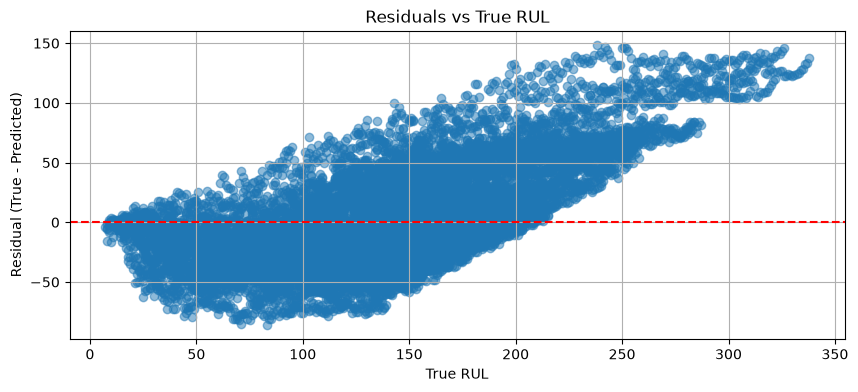

In [475]:
residuals = y_test - y_pred_test

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True RUL")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True RUL")
plt.grid(True)
plt.show()

Model tends to overpredict RUL, hence negative values near smaller RUL.

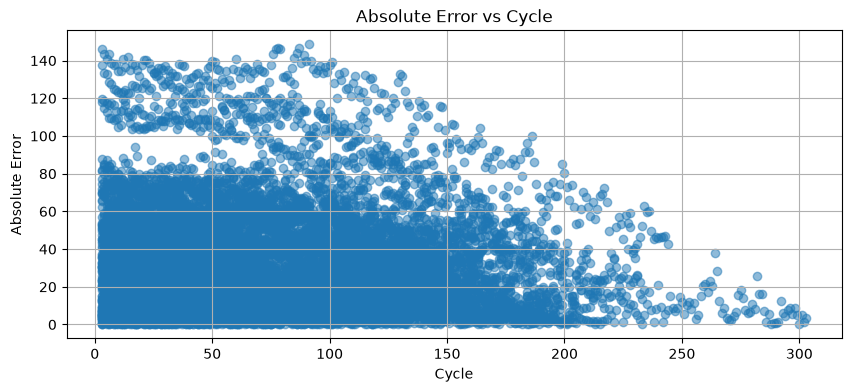

In [476]:
### Error by cycle
plt.figure(figsize=(10, 4))
plt.scatter(test_data_processed["cycle"], np.abs(residuals), alpha=0.5)
plt.xlabel("Cycle")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Cycle")
plt.grid(True)
plt.show()


Error is lower near failure, more accurate closer to failure

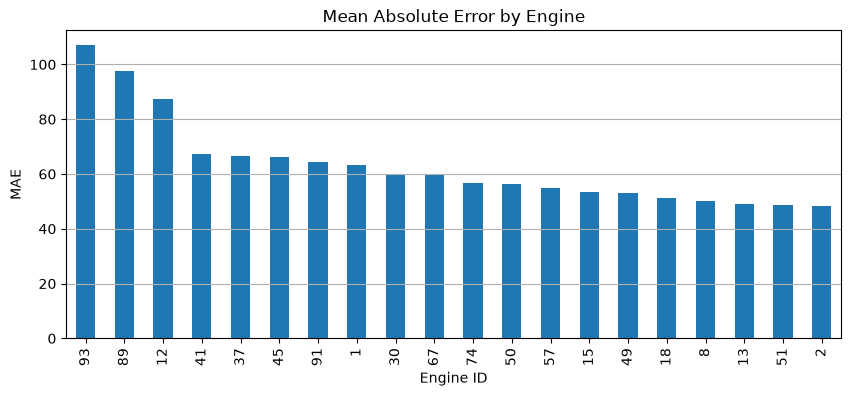

In [477]:
### Error by engine
engine_errors = pd.DataFrame({
    "engine_id": test_data_processed["engine_id"],
    "abs_error": np.abs(residuals)
}).groupby("engine_id")["abs_error"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
engine_errors.head(20).plot(kind="bar")
plt.title("Mean Absolute Error by Engine")
plt.ylabel("MAE")
plt.xlabel("Engine ID")
plt.grid(axis="y")
plt.show()

Engine 93 has the highest errors

# Classification Evaluation via binning


When RUL is below 30 cycles, we treat the engine as being in a near-failure state and flag it for maintenance attention. This is often more actionable from a business perspective than reporting a raw RUL number, because it supports clear operational decisions such as scheduling inspection, maintenance, or replacement.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

# Note: threshold should not be tuned using test set
def binary_evaluation(threshold=30, pred_offset=0):
    # Convert continuous RUL into a binary class: 1 = near failure, 0 = not near failure
    y_true_bin = (y_test <= threshold).astype(int)
    y_pred_bin = (y_pred_test <= threshold + pred_offset).astype(int)

    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    print("Binary Classification Metrics")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_bin, y_pred_bin, target_names=["Not Near Failure", "Near Failure"]))

    # Optional: plot confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Near Failure", "Near Failure"], yticklabels=["Not Near Failure", "Near Failure"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Near-Failure Classification")
    plt.show()


Binary Classification Metrics
Accuracy : 0.9853
Precision: 0.8287
Recall   : 0.5392
F1-score : 0.6533

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       0.99      1.00      0.99     12564
    Near Failure       0.83      0.54      0.65       332

        accuracy                           0.99     12896
       macro avg       0.91      0.77      0.82     12896
    weighted avg       0.98      0.99      0.98     12896



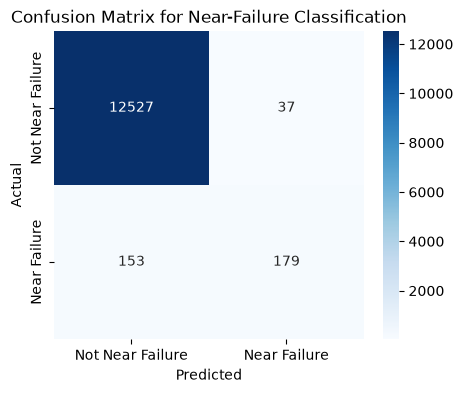

In [497]:
binary_evaluation()

Binary Classification Metrics
Accuracy : 0.9828
Precision: 0.6519
Recall   : 0.7108
F1-score : 0.6801

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       0.99      0.99      0.99     12564
    Near Failure       0.65      0.71      0.68       332

        accuracy                           0.98     12896
       macro avg       0.82      0.85      0.84     12896
    weighted avg       0.98      0.98      0.98     12896



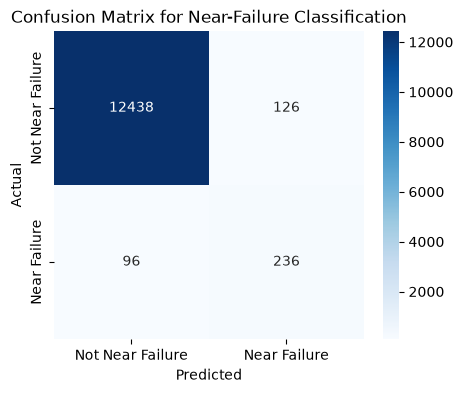

In [503]:
binary_evaluation(pred_offset=10)

Because the model tends to overpredict RUL at lower values, we can apply a positive prediction offset to make the system more conservative and flag more cases as near failure. Increasing the offset generally improves recall but reduces precision, which allows the business to choose the desired tradeoff between catching more risky engines and avoiding extra false alarms.

Example:

Model with offset=0:
- precision = 0.83
- recall = 0.54

Model with offset=10:
- precision = 0.65
- recall = 0.71

## Future work for model improvements

Several next steps could further improve the model and make the results more robust:

- Add a baseline model comparison table, including simple baselines and more advanced models, to better quantify the gain from the current approach.
- Run an ablation study for lag and rolling features to measure how much each feature group contributes to predictive performance.
- Combine multiple datasets or operating conditions to improve generalization and reduce overfitting to a single fleet or regime.
